# EKF Unicycle Robot Localization

Day 5 notebook framework.

目标：使用 nonlinear unicycle motion model、odometry control 和低频 camera position measurement 完成 EKF 定位。

状态：`x = [px, py, theta]`  
控制：`u = [v, omega]`  
观测：`z = [camera_px, camera_py]`

详细要求见 `notes/day05_ekf_unicycle_model.md`。

## 1. 学习边界和参考代码

今天重点：

- nonlinear motion model
- motion Jacobian
- manual EKF prediction
- camera EKF update
- angle normalization

参考：

- `scripts/03_linear_multisensor_fusion.py`
- `source/filterpy/filterpy/kalman/EKF.py`
- `source/filterpy/filterpy/kalman/tests/test_ekf.py`

不做 EKF-SLAM、IMU bias、landmark range-bearing 或 ROS。

## 2. 导入依赖和设置路径

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import ExtendedKalmanFilter

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('e:/申博材料/机器人相关学习/阶段一_基础补齐/01_FilterPy状态估计_移动机器人定位')

## 3. 设置实验参数

先使用统一参数跑通，不要同时修改多组参数。

In [2]:
dt = 0.1
num_steps = 200
initial_state = np.array([0.0, 0.0, 0.0])
true_linear_velocity = 1.0
true_angular_velocity = 0.12

linear_velocity_bias = 0.03
angular_velocity_bias = 0.008
linear_velocity_noise_std = 0.04
angular_velocity_noise_std = 0.01

camera_noise_std = 0.8
camera_interval = 10
dropout_probability = 0.20

position_process_var = 0.01
heading_process_var = 0.005
initial_covariance = 50.0
random_seed = 42

rng = np.random.default_rng(random_seed)

## 4. Angle Normalization

所有 heading 和 heading error 都归一化到 `[-pi, pi)`。

检查：`normalize_angle(3*np.pi)` 应接近 `-np.pi`。

In [3]:
def normalize_angle(angle):
    # TODO: 将 angle 归一化到 [-pi, pi)
    angle = (angle + np.pi) % (2 * np.pi) - np.pi
    return angle


# 完成函数后取消注释
test_angles = np.array([0.0, np.pi, 3*np.pi, -3*np.pi])
normalized_test_angles = normalize_angle(test_angles)
print(normalized_test_angles)  # 输出应为 [0.0, -pi, -pi, -pi]

[ 0.          3.14159265  9.42477796 -9.42477796]


## 5. Nonlinear Unicycle Motion Model

模型：

```text
px' = px + v*cos(theta)*dt
py' = py + v*sin(theta)*dt
theta' = theta + omega*dt
```

输入 state shape `(3,)`，control shape `(2,)`，输出 shape `(3,)`。

In [4]:
def unicycle_motion_model(state, control, dt):
    # TODO 1: 解包 px, py, theta 和 v, omega
    px, py, theta = state
    v, omega = control
    # TODO 2: 根据非线性模型计算 next_state
    next_px = px + v * np.cos(theta) * dt
    next_py = py + v * np.sin(theta) * dt
    next_theta = theta + omega * dt
    # TODO 3: 归一化 next_state[2]
    next_theta = normalize_angle(next_theta)
    # TODO 4: 返回 next_state
    return np.array([next_px, next_py, next_theta])

# 完成后测试 theta=0 时是否主要沿 x 前进
test_state = np.array([0.0, 0.0, 0.0])
test_control = np.array([1.0, 0.0])
next_state = unicycle_motion_model(test_state, test_control, dt)
print(next_state)  # 输出应为 [0.1, 0.0, 0.0]

[0.1 0.  0. ]


## 6. Motion Jacobian

对状态 `[px, py, theta]` 的 Jacobian：

```text
F = [[1, 0, -v*sin(theta)*dt],
     [0, 1,  v*cos(theta)*dt],
     [0, 0,  1]]
```

Jacobian 用于传播协方差，不直接替代 nonlinear state prediction。

In [ ]:
def motion_jacobian(state, control, dt):
    # TODO 1: 读取 theta 和 v
    theta = state[2]
    v = control[0]
    # TODO 2: 构造 3x3 Jacobian
    F = np.array([
        [1, 0, -v * np.sin(theta) * dt],
        [0, 1, v * np.cos(theta) * dt],
        [0, 0, 1]
    ])
    # TODO 3: 返回 F
    return F

motion_jacobian_test = motion_jacobian(
    state = test_state,
    control = test_control,
    dt = dt
)

# 完成后打印 shape，应为 (3, 3)
print("Jacobian shape:", motion_jacobian_test.shape)  # 输出应为 (3, 3)

Jacobian shape: (3, 3)


## 7. Camera Measurement Function and Jacobian

Camera 只测位置：`z = [px, py]`。

`Hx(state)` shape 为 `(2,)`，`HJacobian(state)` shape 为 `(2, 3)`。

In [7]:
def camera_measurement_function(state):
    # TODO: 返回 state 中的 px, py
    px, py = state[0], state[1]
    return np.array([px, py])


def camera_measurement_jacobian(state):
    # TODO: 返回 shape=(2, 3) 的观测 Jacobian
    measurement_jacobian = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
    ])
    return measurement_jacobian

camera_measurement_test_state = camera_measurement_function(test_state)
camera_measurement_jacobian_test_state = camera_measurement_jacobian(test_state)
print("Camera measurement:", camera_measurement_test_state)  # 输出应为 [0.0, 0.0]
print("camera_measurement_jacobian", camera_measurement_jacobian_test_state)
print("Camera measurement Jacobian shape:", camera_measurement_jacobian_test_state.shape)  # 输出应为 (2, 3)

Camera measurement: [0. 0.]
camera_measurement_jacobian [[1. 0. 0.]
 [0. 1. 0.]]
Camera measurement Jacobian shape: (2, 3)


## 8. 生成 Ground Truth

创建 constant `v, omega` 控制序列，并使用 nonlinear motion model 逐步生成真实状态。

输出：

- `times`: `(num_steps,)`
- `true_controls`: `(num_steps, 2)`
- `true_states`: `(num_steps, 3)`

In [16]:
def generate_unicycle_ground_truth(num_steps, dt, initial_state,
                                      true_linear_velocity, true_angular_velocity):
    # TODO 1: 创建 times、controls、states
    times = np.arange(num_steps) * dt
    controls = np.tile(
        np.array([
            [true_linear_velocity, true_angular_velocity]
        ]),
        (num_steps, 1) 
    )
    # TODO 2: 设置 states[0]
    states = np.zeros((num_steps, 3))
    states[0] = initial_state
    # TODO 3: 从 i=1 开始使用 motion model 积分
    for i in range(1, num_steps):
        states[i] = unicycle_motion_model(states[i-1], controls[i-1], dt)
    # TODO 4: 返回 times, controls, states
    return times, controls, states
    
times, true_controls, true_states = generate_unicycle_ground_truth(
    num_steps=num_steps,
    dt=dt,
    initial_state=initial_state,
    true_linear_velocity=true_linear_velocity,
    true_angular_velocity=true_angular_velocity
)
print("times", times.shape)  # 输出应为 (200,)
print("true_controls", true_controls.shape)  # 输出应为 (200, 2)
print("true_states", true_states.shape)  # 输出应为 (200, 3)

times (200,)
true_controls (200, 2)
true_states (200, 3)


## 9. 模拟 Odometry Controls

对 `v` 和 `omega` 分别加入 bias 和 Gaussian noise。

输出 `odometry_controls` shape `(num_steps, 2)`。

In [14]:
def simulate_odometry_controls(true_controls, linear_velocity_bias, angular_velocity_bias,
                               linear_velocity_noise_std, angular_velocity_noise_std, rng):
    # TODO 1: 分别生成 v 和 omega noise
    v_noise = rng.normal(
        loc = 0.0,
        scale = linear_velocity_noise_std,
        size = true_controls.shape[0]
    )
    omega_noise = rng.normal(
        loc = 0.0,
        scale = angular_velocity_noise_std,
        size = true_controls.shape[0]
    )
    # TODO 2: true control + bias + noise
    odometry_controls = true_controls.copy()
    odometry_controls[:, 0] += linear_velocity_bias + v_noise
    odometry_controls[:, 1] += angular_velocity_bias + omega_noise
    # TODO 3: 返回 odometry_controls
    return odometry_controls


def integrate_odometry_only(initial_state, odometry_controls, dt):
    # TODO: 使用同一个 nonlinear motion model 积分 odometry-only states
    odometry_states = np.zeros((odometry_controls.shape[0], 3))
    odometry_states[0] = initial_state
    for i in range(1, odometry_controls.shape[0]):
        odometry_states[i] = unicycle_motion_model(odometry_states[i-1], odometry_controls[i-1], dt)
    return odometry_states

## 10. 模拟 Camera Position Measurements

复用 Day 4 的 interval、noise、dropout 和 availability mask。

无测量位置保持 `NaN`，不要填 `[0, 0]`。

In [20]:
def simulate_camera_measurements(true_states, camera_noise_std, camera_interval,
                                 dropout_probability, rng):
    num_steps = len(true_states)
    camera_measurements = np.full((num_steps, 2), np.nan)
    camera_available = np.zeros(num_steps, dtype=bool)

    # TODO: 仅在采样且未 dropout 时生成 noisy [px, py]
    for i in range(num_steps):
        if i % camera_interval == 0 and rng.uniform() > dropout_probability:
            noise = rng.normal(
                loc = 0.0,
                scale = camera_noise_std,
                size = 2
            )
            camera_measurements[i, 0] = true_states[i, 0] + noise[0]
            camera_measurements[i, 1] = true_states[i, 1] + noise[1]
            camera_available[i] = True
    return camera_measurements, camera_available

camera_measurements, camera_available = simulate_camera_measurements(
    true_states=true_states,
    camera_noise_std=camera_noise_std,
    camera_interval=camera_interval,
    dropout_probability=dropout_probability,
    rng=rng
)
print("valid camera measurements:", camera_available.sum())
print("camera_measurements shape:", camera_measurements.shape)

valid camera measurements: 16
camera_measurements shape: (200, 2)


## 11. 创建 Extended Kalman Filter

配置：

- `dim_x=3`
- `dim_z=2`
- `x=[px, py, theta]`
- `P`: `(3, 3)`
- `Q`: `(3, 3)`
- `R`: `(2, 2)`

In [22]:
def create_ekf(initial_state, initial_covariance, position_process_var,
               heading_process_var, camera_noise_std):
    ekf = ExtendedKalmanFilter(dim_x=3, dim_z=2)

    # TODO 1: 设置 ekf.x 和 ekf.P
    ekf.x = np.array(initial_state)
    ekf.P = np.eye(3) * initial_covariance
    # TODO 2: Q 的前两个对角项使用 position_process_var
    # TODO 3: Q 的 theta 对角项使用 heading_process_var
    ekf.Q = np.diag([
        position_process_var, 
        position_process_var, 
        heading_process_var
    ])
    # TODO 4: 设置 2x2 camera R
    ekf.R = np.diag([
        camera_noise_std**2, 
        camera_noise_std**2
    ])

    return ekf

## 12. 运行 EKF Localization

每一步：

1. 保存 `state_before`。
2. 用 `motion_jacobian(state_before, control, dt)` 计算 F。
3. 用 nonlinear motion model 更新 `ekf.x`。
4. 用 `P = F @ P @ F.T + Q` 传播协方差。
5. Camera 可用时调用 `ekf.update(z, HJacobian, Hx)`。
6. 归一化 `theta`。
7. 保存状态。

In [26]:
def run_ekf_localization(
        odometry_controls, 
        camera_measurements,
        camera_available, 
        dt, 
        initial_state,
        initial_covariance, 
        position_process_var,
        heading_process_var, 
        camera_noise_std):
    # TODO 1: 创建 EKF 和 states 数组
    ekf = create_ekf(
        initial_state,
        initial_covariance,
        position_process_var,
        heading_process_var,
        camera_noise_std,
    )
    ekf_states = np.zeros((odometry_controls.shape[0], 3))
    # TODO 2: 处理第 0 步 camera update
    if camera_available[0]:
        ekf.update(
            z=camera_measurements[0],
            HJacobian=camera_measurement_jacobian,
            Hx=camera_measurement_function
        )
    ekf.x[2] = normalize_angle(ekf.x[2])
    ekf_states[0] = ekf.x

    # TODO 3: 从 i=1 开始 nonlinear prediction
    for i in range(1, odometry_controls.shape[0]):
        state_before = ekf.x.copy()
        control = odometry_controls[i - 1]

        # Jacobian必须根据预测前的状态计算
        F = motion_jacobian(state_before, control, dt)

        # 非线性状态预测
        ekf.x = unicycle_motion_model(
            state_before,
            control,
            dt,
        )

        # 协方差预测
        ekf.P = F @ ekf.P @ F.T + ekf.Q

    # TODO 4: camera 可用时 update，不可用时跳过
        if camera_available[i]:
            ekf.update(
                z=camera_measurements[i],
                HJacobian=camera_measurement_jacobian,
                Hx=camera_measurement_function
            )
    # TODO 5: 每一步归一化 theta 并保存 state
        ekf.x[2] = normalize_angle(ekf.x[2])
        ekf_states[i] = ekf.x
    # TODO 6: 返回 ekf_states
    return ekf_states

odometry_controls = simulate_odometry_controls(
    true_controls=true_controls,
    linear_velocity_bias=linear_velocity_bias,
    angular_velocity_bias=angular_velocity_bias,
    linear_velocity_noise_std=linear_velocity_noise_std,
    angular_velocity_noise_std=angular_velocity_noise_std,
    rng=rng,
)

odometry_states = integrate_odometry_only(
    initial_state=initial_state,
    odometry_controls=odometry_controls,
    dt=dt,
)

ekf_states = run_ekf_localization(
    odometry_controls=odometry_controls,
    camera_measurements=camera_measurements,
    camera_available=camera_available,
    dt=dt,
    initial_state=initial_state,
    initial_covariance=initial_covariance,
    position_process_var=position_process_var,
    heading_process_var=heading_process_var,
    camera_noise_std=camera_noise_std,
)

print("ekf_states shape:", ekf_states.shape)  # 输出应为 (200, 3)
print("ekf_states:", ekf_states)

ekf_states shape: (200, 3)
ekf_states: [[ 1.24051001e-01 -1.25303979e-01  0.00000000e+00]
 [ 2.25278953e-01 -1.25303979e-01  1.50141526e-02]
 [ 3.28108536e-01 -1.23759964e-01  2.73622016e-02]
 [ 4.32839137e-01 -1.20893588e-01  3.94963239e-02]
 [ 5.34542052e-01 -1.16874607e-01  5.27303337e-02]
 [ 6.35762572e-01 -1.11532263e-01  6.57821882e-02]
 [ 7.38908414e-01 -1.04737300e-01  7.71773966e-02]
 [ 8.33941022e-01 -9.73883336e-02  9.11000749e-02]
 [ 9.38414136e-01 -8.78444081e-02  1.03805880e-01]
 [ 1.04085745e+00 -7.71718277e-02  1.15494949e-01]
 [ 3.55878750e-01 -2.91837429e-01 -4.39733148e-02]
 [ 4.62618405e-01 -2.96534154e-01 -3.05476392e-02]
 [ 5.57762733e-01 -2.99441493e-01 -1.90121812e-02]
 [ 6.52850210e-01 -3.01249531e-01 -4.43499835e-03]
 [ 7.56944401e-01 -3.01711191e-01  9.02379902e-03]
 [ 8.59911742e-01 -3.00782010e-01  2.18136029e-02]
 [ 9.63567783e-01 -2.98520539e-01  3.62038217e-02]
 [ 1.06465299e+00 -2.94859268e-01  4.91631195e-02]
 [ 1.17018274e+00 -2.89666913e-01  6.193503

## 13. 中间检查

完成以上函数后，先检查：

```text
true_states          (200, 3)
true_controls        (200, 2)
odometry_controls    (200, 2)
odometry_states      (200, 3)
camera_measurements  (200, 2)
camera_available     (200,)
ekf_states           (200, 3)
```

并确认全部 heading 在 `[-pi, pi)`。

In [27]:
# TODO: 完成前面函数后，在此调用并打印所有数组 shape
print("true_states shape:", true_states.shape)  # 输出应为 (200, 3)
print("true_controls shape:", true_controls.shape)  # 输出应为 (200, 2)
print("odometry_controls shape:", odometry_controls.shape)  # 输出应为 (200, 2)
print("odometry_states shape:", odometry_states.shape)  # 输出应为 (200, 3)
print("camera_measurements shape:", camera_measurements.shape)  # 输出应为 (200, 2)
print("camera_available shape:", camera_available.shape)  # 输出应为 (200,)
print("ekf_states shape:", ekf_states.shape)  # 输出应为 (200, 3)
# 不要在 shape 未确认前直接绘制最终图

true_states shape: (200, 3)
true_controls shape: (200, 2)
odometry_controls shape: (200, 2)
odometry_states shape: (200, 3)
camera_measurements shape: (200, 2)
camera_available shape: (200,)
ekf_states shape: (200, 3)


## 14. RMSE

需要计算：

- Odometry position RMSE
- EKF position RMSE
- Camera position RMSE（仅有效时刻）
- Odometry heading RMSE
- EKF heading RMSE

Heading error 必须先 normalize。

In [31]:
def compute_position_rmse(estimated_positions, true_positions):
    # TODO: 复用 Day 4 的二维欧氏距离 RMSE
    position_errors = estimated_positions - true_positions
    squared_distances = np.sum(position_errors ** 2, axis = 1)
    mean_squared_distance = np.mean(squared_distances)
    rmse = np.sqrt(mean_squared_distance)
    return rmse


def compute_heading_rmse(estimated_heading, true_heading):
    # TODO 1: normalize heading difference
    heading_difference = normalize_angle(
        estimated_heading - true_heading
    )
    # TODO 2: 计算 RMSE
    mean_squared_error = np.mean(heading_difference ** 2)
    rmse = np.sqrt(mean_squared_error)
    return rmse


# TODO: 生成 rmse_table 并保存 results/ekf_unicycle_rmse.csv

odometry_position_rmse = compute_position_rmse(
    estimated_positions = odometry_states[:, :2],
    true_positions = true_states[:, :2]
)

ekf_position_rmse = compute_position_rmse(
    estimated_positions=ekf_states[:, :2],
    true_positions=true_states[:, :2],
)

camera_position_rmse = compute_position_rmse(
    estimated_positions=camera_measurements[camera_available],
    true_positions=true_states[camera_available, :2],
)

odometry_heading_rmse = compute_heading_rmse(
    estimated_heading=odometry_states[:, 2],
    true_heading=true_states[:, 2],
)

ekf_heading_rmse = compute_heading_rmse(
    estimated_heading=ekf_states[:, 2],
    true_heading=true_states[:, 2],
)


rmse_table = pd.DataFrame({
    "method": [
        "odometry_only",
        "camera_measurement",
        "ekf",
    ],
    "position_rmse": [
        odometry_position_rmse,
        camera_position_rmse,
        ekf_position_rmse,
    ],
    "heading_rmse_rad": [
        odometry_heading_rmse,
        np.nan,
        ekf_heading_rmse,
    ],
    "heading_rmse_deg": [
        np.degrees(odometry_heading_rmse),
        np.nan,
        np.degrees(ekf_heading_rmse),
    ],
    "evaluation_steps": [
        len(true_states),
        int(camera_available.sum()),
        len(true_states),
    ],
})



rmse_output_path = RESULTS_DIR / "ekf_unicycle_rmse.csv"

rmse_table.to_csv(
    rmse_output_path,
    index=False,
)

# print(rmse_table)
print("RMSE saved to:", rmse_output_path)
rmse_table

RMSE saved to: e:\申博材料\机器人相关学习\阶段一_基础补齐\01_FilterPy状态估计_移动机器人定位\results\ekf_unicycle_rmse.csv


,method,position_rmse,heading_rmse_rad,heading_rmse_deg,evaluation_steps
0,odometry_only,0.598178,0.095552,5.474717,200
1,camera_measurement,1.021122,NaN,NaN,16
2,ekf,0.779554,0.236071,13.525873,200


## 15. 绘图

需要生成：

1. `figures/ekf_unicycle_trajectory.png`
2. `figures/ekf_unicycle_position_error.png`
3. `figures/ekf_unicycle_heading_error.png`

每个函数保存后使用 `plt.close(fig)`。

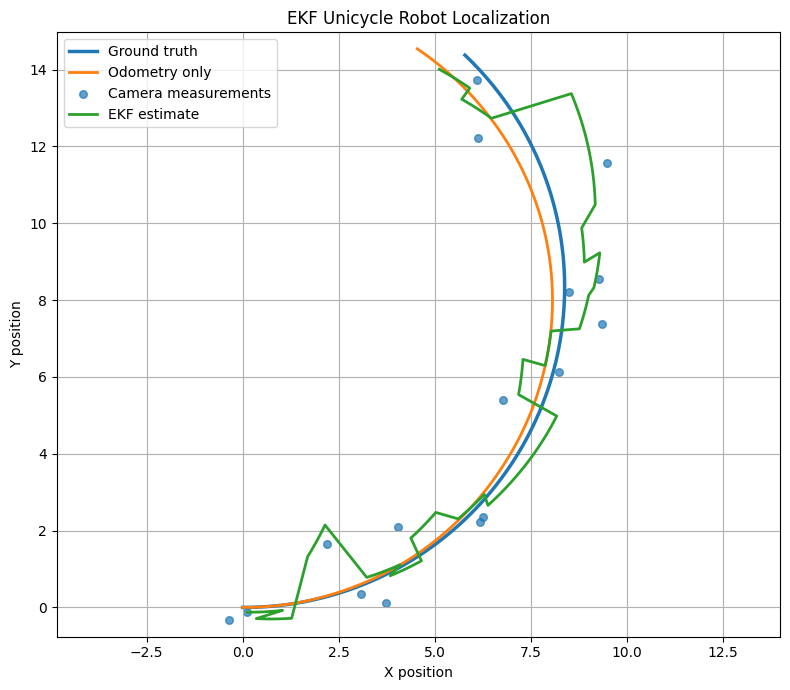

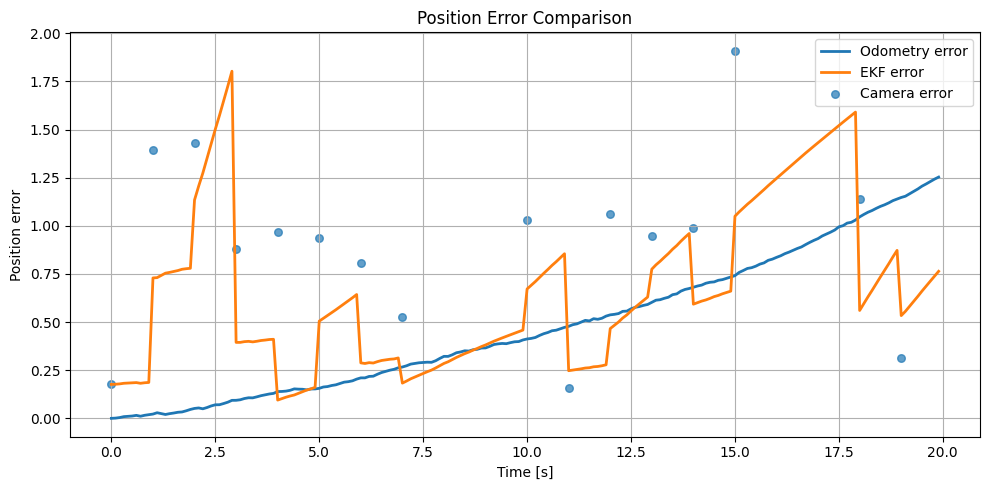

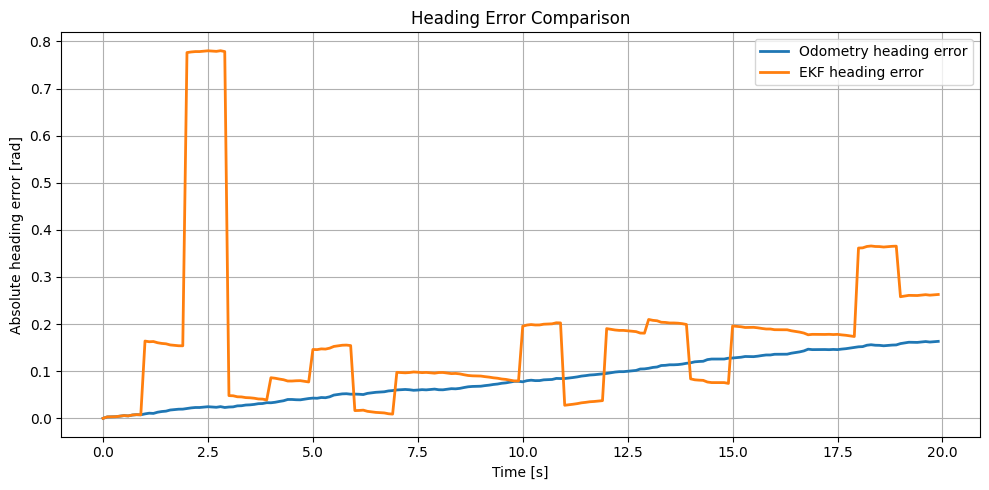

In [32]:
def plot_trajectory(
        true_states, 
        odometry_states, 
        camera_measurements,
        camera_available, 
        ekf_states, 
        output_path
    ):
    # TODO: 画 ground truth、odometry、camera、EKF
    fig, ax = plt.subplots(figsize=(8, 7))

    ax.plot(
        true_states[:, 0],
        true_states[:, 1],
        linewidth=2.5,
        label="Ground truth",
    )

    ax.plot(
        odometry_states[:, 0],
        odometry_states[:, 1],
        linewidth=2,
        label="Odometry only",
    )

    ax.scatter(
        camera_measurements[camera_available, 0],
        camera_measurements[camera_available, 1],
        s=30,
        alpha=0.7,
        label="Camera measurements",
    )

    ax.plot(
        ekf_states[:, 0],
        ekf_states[:, 1],
        linewidth=2,
        label="EKF estimate",
    )

    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.set_title("EKF Unicycle Robot Localization")
    ax.legend()
    ax.grid(True)
    ax.axis("equal")

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)


def plot_position_error(
        times, 
        true_states, 
        odometry_states,
        camera_measurements, 
        camera_available,
        ekf_states, 
        output_path
    ):
    # TODO: 画 odometry、camera、EKF position error
    odometry_error = np.linalg.norm(
        odometry_states[:, :2] - true_states[:, :2],
        axis=1,
    )

    ekf_error = np.linalg.norm(
        ekf_states[:, :2] - true_states[:, :2],
        axis=1,
    )

    camera_error = np.linalg.norm(
        camera_measurements[camera_available]
        - true_states[camera_available, :2],
        axis=1,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        times,
        odometry_error,
        linewidth=2,
        label="Odometry error",
    )

    ax.plot(
        times,
        ekf_error,
        linewidth=2,
        label="EKF error",
    )

    ax.scatter(
        times[camera_available],
        camera_error,
        s=30,
        alpha=0.7,
        label="Camera error",
    )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Position error")
    ax.set_title("Position Error Comparison")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)


def plot_heading_error(
        times, 
        true_states, 
        odometry_states,
        ekf_states, 
        output_path
    ):
    # TODO: normalize 后画 odometry 和 EKF heading error
    odometry_heading_error = np.abs(
        normalize_angle(
            odometry_states[:, 2] - true_states[:, 2]
        )
    )

    ekf_heading_error = np.abs(
        normalize_angle(
            ekf_states[:, 2] - true_states[:, 2]
        )
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        times,
        odometry_heading_error,
        linewidth=2,
        label="Odometry heading error",
    )

    ax.plot(
        times,
        ekf_heading_error,
        linewidth=2,
        label="EKF heading error",
    )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Absolute heading error [rad]")
    ax.set_title("Heading Error Comparison")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)



plot_trajectory(
    true_states=true_states,
    odometry_states=odometry_states,
    camera_measurements=camera_measurements,
    camera_available=camera_available,
    ekf_states=ekf_states,
    output_path=FIGURES_DIR / "ekf_unicycle_trajectory.png",
)

plot_position_error(
    times=times,
    true_states=true_states,
    odometry_states=odometry_states,
    camera_measurements=camera_measurements,
    camera_available=camera_available,
    ekf_states=ekf_states,
    output_path=FIGURES_DIR / "ekf_unicycle_position_error.png",
)

plot_heading_error(
    times=times,
    true_states=true_states,
    odometry_states=odometry_states,
    ekf_states=ekf_states,
    output_path=FIGURES_DIR / "ekf_unicycle_heading_error.png",
)


## 16. 验收和结果记录

完成后执行 `Restart Kernel and Run All`，确认：

- Ground truth 是弯曲轨迹。
- Odometry 存在位置和 heading 漂移。
- Camera 稀疏、有噪声和 dropout。
- EKF 轨迹连续并被 camera 修正。
- EKF position RMSE 小于 odometry-only。

然后填写 `notes/day05_ekf_unicycle_model.md` 第 20 节。

## 17. Notebook 跑通后再整理 Python 脚本

目标文件：

`scripts/04_ekf_unicycle_model.py`

整理前检查：

- Notebook 没有核心 TODO。
- 所有 cell 从头运行。
- 三张图和 CSV 已更新。
- 参数、状态顺序、随机种子和时间索引已确认。